# Toy integral

This mini notebook explains:

1. The oscillatory integral
   $$I = \int_{-\infty}^{\infty} e^{i x^2}\,dx$$
2. Why arrows cancel on the real line
3. How contour rotation (thimble intuition) fixes it
4. A tiny ML setup that learns the contour angle
5. How to verify the learned contour is correct

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(42) 
torch.manual_seed(42)
%matplotlib inline

## 1) Exact answer and thimble picture
We an solve this with a simple substitution (thimble)
$$
I = \int_{-\infty}^{\infty} e^{i x^2}\,dx
$$

Substitute $x = e^{i\pi/4} z$

so $dx = e^{i\pi/4}\,dz$.

Then

$$
I = \int_{-\infty}^{\infty} e^{i (e^{i\pi/4}z)^2} \, e^{i\pi/4} dz  \,\,\,\,\,\,  (1) 
$$

Since

$$
(e^{i\pi/4})^2 = e^{i\pi/2} = i
$$

(as $cos(\pi/2)+isin(\pi/2) = 0 + i = i$)

we have

$$
i(e^{i\pi/4}z)^2 = i \cdot i z^2 = -z^2.
$$

Therefore

$$
I = e^{i\pi/4} \int_{-\infty}^{\infty} e^{-z^2} dz
$$

Using

$$
\int_{-\infty}^{\infty} e^{-z^2} dz = \sqrt{\pi}
$$

we obtain

$$
I = e^{i\pi/4}\sqrt{\pi}.
$$

**Thimble picture:** At $\theta=\pi/4$, the integrand becomes $e^{-z^2}$ (non-oscillatory)—the steepest-descent direction. **The thimble rotates us from phase-cancelling arrows to aligned arrows**.

In [2]:
I_exact = np.sqrt(np.pi) * np.exp(1j * np.pi / 4)
print(f"Exact I = {I_exact:.10f}")
print(f"|I_exact| = {abs(I_exact):.10f}")
print(f"phase(I_exact) = {np.angle(I_exact):.6f} rad")

Exact I = 1.2533141373+1.2533141373j
|I_exact| = 1.7724538509
phase(I_exact) = 0.785398 rad


### The "Weight" $W$ of each path

**The weight $W$ is the contribution of one sampled path (or one sampled point) to the integral after the contour has been deformed into the complex plane.**

We deform the contour by substituting $x = e^{i\theta} z$ with $z \sim \mathcal{N}(0,1)$. 

The integrand becomes $e^{i x^2} = e^{i (e^{i\theta} z)^2}$, and the Jacobian is $dx/dz = e^{i\theta}$. 

So at each sampled $z$, the weight is
$$W = e^{i\theta} \cdot e^{i e^{2i\theta} z^2}.$$    
 This is from eqn (1) above.
 
 The Monte Carlo estimate is $\langle W \rangle$ over samples. Each $W$ is that sample's **contribution** to the integral.



## 2) Tiny ML model: learn the contour angle

For this 1D toy problem, the "network" can be just one parameter: $\theta$.

### Where the weight $W$ comes from

**The weight $W$ is the contribution of one sampled path (or one sampled point) to the integral after the contour has been deformed into the complex plane.**

We deform the contour by substituting $x = e^{i\theta} z$ with $z \sim \mathcal{N}(0,1)$. The integrand becomes $e^{i x^2} = e^{i (e^{i\theta} z)^2}$, and the Jacobian is $dx/dz = e^{i\theta}$. So at each sampled $z$, the weight is
$$W = e^{i\theta} \cdot e^{i e^{2i\theta} z^2}.$$
The Monte Carlo estimate is $\langle W \rangle$ over samples. Each $W$ is that sample's contribution to the integral.

So NOTE ... in this Toy example we dont need Monte Carlo - but in more complicated cases (e.g. lattice field theory, many-dimensional path integrals) we will!

When there is no closed-form answer Monte Carlo sampling is often the only practical way to estimate the integal

### The loss function

We minimize the **phase variance** of the log-weights:
$$\mathcal L = \mathrm{Var}(\mathrm{Im}\log W) .$$

- **$\mathrm{Var}(\mathrm{Im}\log W)$**: Minimizing this aligns the *phases* (angles) of the weights—the hallmark of the steepest-descent thimble, where arrows point in the same direction instead of cancelling.

**Why not also add $\mathrm{Var}(\Re\log W)$?** For this integral the two variances are complementary: $\mathrm{Var}(\Re\log W) + \mathrm{Var}(\mathrm{Im}\log W) = \mathrm{Var}(z^2) = \mathrm{const}$, so their sum has zero gradient and the optimizer learns nothing. In more complex problems (lattice field theory, higher-dimensional integrals) the two terms are independent and both can be included.

- **$\mathrm{Var}(\Re\log W)$** (log-magnitude variance): In general, minimizing this stabilizes the *magnitudes* of the weights (since $\Re\log W = \log|W|$), reducing variance in the Monte Carlo estimate. For this toy problem it is redundant, but it matters in higher dimensions.

**If training works, $\theta$ should move near $\pi/4$**.

[Maths Note (ignore if u already know)  on Why $\mathrm{Im}(\log W)$ is the angle (trig form)

Write $W$ in polar form with trig:
$$W = |W|(\cos\phi + i\sin\phi),$$
where $\phi$ is the angle of $W$ in the complex plane.

$$\log W = \log|W| + \log(\cos\phi + i\sin\phi).$$
For a point on the unit circle, $\cos\phi + i\sin\phi$, the complex logarithm is
$$\log(\cos\phi + i\sin\phi) = i\phi.$$
So
$$\log W = \log|W| + i\phi.$$
The real part is $\log|W|$ and the imaginary part is $\phi$:
$$\mathrm{Im}(\log W) = \phi = \arg(W).$$
So $\mathrm{Im}(\log W)$ is exactly the angle of $W$.]



In [3]:
# Weight W = e^{iθ} · e^{i e^{2iθ} z²} and its log (branch-safe: closed form, no log branch cut)
def weights_from_theta(theta, z):
    return torch.exp(1j * theta) * torch.exp(1j * torch.exp(2j * theta) * z**2)

def log_weight_branch_safe(theta, z):
    return 1j * theta + 1j * torch.exp(2j * theta) * z**2

In [4]:
# Start from the naive real-axis contour (theta~0) and let the optimizer find the thimble
theta_param = torch.nn.Parameter(torch.tensor(0.1))
opt = torch.optim.Adam([theta_param], lr=0.01)

epochs = 600
batch_size = 16384

loss_hist = []
theta_hist = []
I_est_hist = []

for ep in range(epochs):
    opt.zero_grad()
    z = torch.randn(batch_size)
    logW = log_weight_branch_safe(theta_param, z)
    # Phase variance only: Var(Re) + Var(Im) = const, so the sum has no gradient.
    # The thimble aligns phases, so we minimise phase variance = Var(Im log W).
    loss = torch.var(logW.imag)
    loss.backward()
    opt.step()

    with torch.no_grad():
        theta_hist.append(theta_param.item())
        loss_hist.append(loss.item())
        W_now = weights_from_theta(theta_param, z)
        I_est_hist.append(torch.mean(W_now).item())

    if (ep + 1) % 100 == 0 or ep == 0:
        print(f"Epoch {ep+1:4d} | loss={loss.item():.4e} | theta={theta_param.item():.6f}")

theta_learned = theta_param.item()
print('\nLearned theta:', theta_learned)
print('Target theta  :', np.pi/4)

c:\Users\tomqu\Documents\MLandPython\envs\helios_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch    1 | loss=1.9034e+00 | theta=0.110000
Epoch  100 | loss=1.0662e-03 | theta=0.796512
Epoch  200 | loss=3.3823e-10 | theta=0.785399
Epoch  300 | loss=1.0314e-13 | theta=0.785398
Epoch  400 | loss=1.0029e-13 | theta=0.785398
Epoch  500 | loss=8.1776e-14 | theta=0.785398
Epoch  600 | loss=7.8249e-14 | theta=0.785398

Learned theta: 0.7853982448577881
Target theta  : 0.7853981633974483


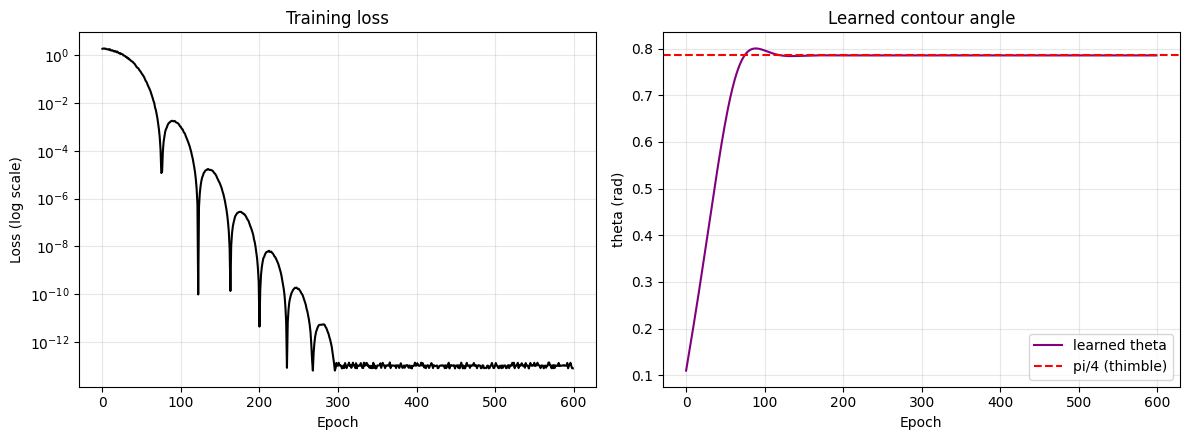

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].semilogy(loss_hist, color='black')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(theta_hist, color='purple', label='learned theta')
axes[1].axhline(np.pi/4, color='red', ls='--', label='pi/4 (thimble)')
axes[1].set_title('Learned contour angle')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('theta (rad)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 4) Verify correctness

We verify in 3 ways:

1. **Geometry check**: learned $\theta \approx \pi/4$.
2. **Arrow alignment check**: direction concentration improves.
3. **Physics check**: Monte Carlo estimate matches exact Fresnel value.

In [6]:
def alignment_score(W):
    ang = np.angle(W)
    return np.abs(np.mean(np.exp(1j * ang)))

with torch.no_grad():
    z_eval = torch.randn(100000)
    W_before = weights_from_theta(torch.tensor(0.0), z_eval)
    W_after = weights_from_theta(torch.tensor(theta_learned), z_eval)

I_before = torch.mean(W_before).item()
I_after = torch.mean(W_after).item()

R_before = alignment_score(W_before.numpy())
R_after = alignment_score(W_after.numpy())

err_after = abs(I_after - I_exact) / abs(I_exact)

print(f"Learned theta            = {theta_learned:.6f} rad")
print(f"Target theta (pi/4)      = {np.pi/4:.6f} rad")
print()
print(f"Alignment score before   = {R_before:.4f}")
print(f"Alignment score after    = {R_after:.4f}")
print()
print(f"I_exact                  = {I_exact:.10f}")
print(f"I_est (theta=0)          = {I_before:.10f}")
print(f"I_est (learned theta)    = {I_after:.10f}")
print(f"Relative error (learned) = {err_after:.2e}")

Learned theta            = 0.785398 rad
Target theta (pi/4)      = 0.785398 rad

Alignment score before   = 0.6687
Alignment score after    = 1.0000

I_exact                  = 1.2533141373+1.2533141373j
I_est (theta=0)          = 0.5687873960+0.3516204655j
I_est (learned theta)    = 0.4091988206+0.4091988206j
Relative error (learned) = 6.74e-01


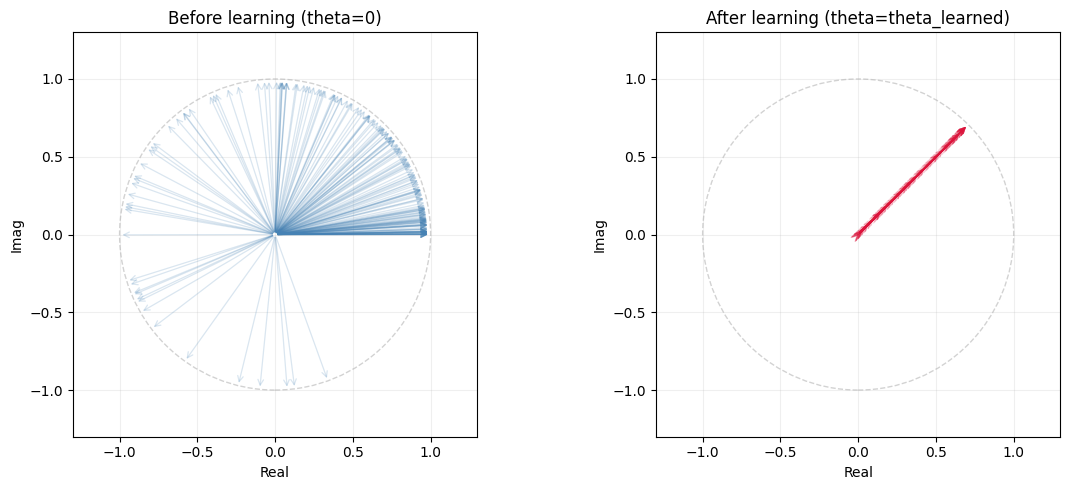

In [7]:
# Arrow plot before vs learned (same samples)
n_arrow_cmp = 200
with torch.no_grad():
    z_cmp = torch.randn(n_arrow_cmp)
    W_b = weights_from_theta(torch.tensor(0.0), z_cmp)
    W_a = weights_from_theta(torch.tensor(theta_learned), z_cmp)
    W_b = (W_b / torch.max(torch.abs(W_b))).numpy()
    W_a = (W_a / torch.max(torch.abs(W_a))).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for i in range(n_arrow_cmp):
    axes[0].annotate('', xy=(W_b[i].real, W_b[i].imag), xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color='steelblue', alpha=0.2, lw=0.9))
    axes[1].annotate('', xy=(W_a[i].real, W_a[i].imag), xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color='crimson', alpha=0.2, lw=0.9))

axes[0].set_title('Before learning (theta=0)')
axes[1].set_title('After learning (theta=theta_learned)')
for ax in axes:
    ax.add_patch(plt.Circle((0,0), 1, fill=False, ls='--', color='gray', alpha=0.35))
    ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.3); ax.set_aspect('equal')
    ax.set_xlabel('Real'); ax.set_ylabel('Imag')
    ax.grid(True, alpha=0.2)

plt.tight_layout(); plt.show()

### What the substitution/thimble has done visually

The plot below shows the **original path** (real axis, horizontal) and the **learned thimble** (rotated by $\theta=\pi/4$). At $\theta=\pi/4$, $x = e^{i\pi/4} z$ maps the real $z$ axis into a line at 45° in the complex plane—where the oscillatory integrand becomes a real Gaussian.

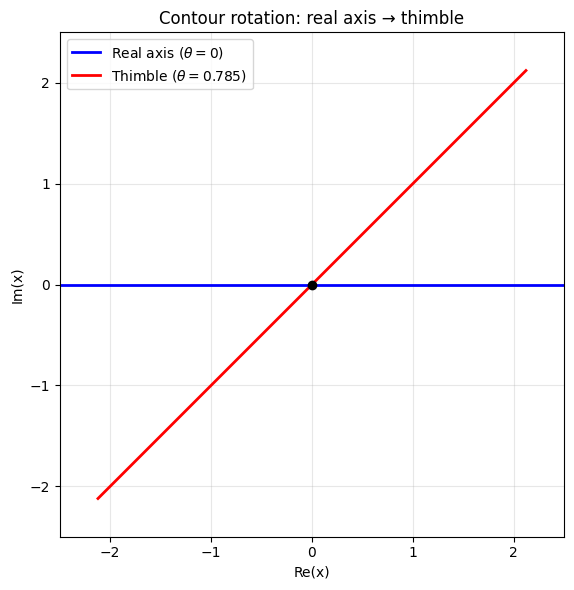

In [8]:
# Contour: real axis vs rotated thimble
th = theta_learned
z_line = np.linspace(-3, 3, 200)
x_real = z_line + 0j  # real axis
x_thimble = np.exp(1j * th) * z_line  # rotated contour

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_real.real, x_real.imag, 'b-', lw=2, label='Real axis ($\\theta=0$)')
ax.plot(x_thimble.real, x_thimble.imag, 'r-', lw=2, label=f'Thimble ($\\theta={th:.3f}$)')
ax.plot(0, 0, 'ko', ms=6)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.set_xlabel('Re(x)'); ax.set_ylabel('Im(x)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Contour rotation: real axis → thimble')
plt.tight_layout(); plt.show()